# UMNG - Análisis de Plataforma

## Joomla + PostgreSQL + Docker

Este notebook consulta directamente la base de datos PostgreSQL utilizada por Joomla.

Los datos mostrados son obtenidos en tiempo real desde la infraestructura Docker.


## 1. Conexión con PostgreSQL

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import sqlalchemy as sa
from sqlalchemy.engine import URL

host = os.getenv("POSTGRES_HOST", "database")
puerto = int(os.getenv("POSTGRES_PORT", "5432"))
bd = os.getenv("POSTGRES_DB", "joomladb")
usuario = os.getenv("POSTGRES_USER", "joomlauser")
password = os.getenv("POSTGRES_PASSWORD", "joomlapassword")

url = URL.create(
    "postgresql+psycopg2",
    username=usuario,
    password=password,
    host=host,
    port=puerto,
    database=bd
)

engine = sa.create_engine(url)

with engine.connect() as conexion:
    version = conexion.execute(
        sa.text("SELECT version();")
    ).scalar()

print("Conexion exitosa a PostgreSQL")
print("Base de datos:", bd)
print("Servidor:", host)
print(version.split(",")[0])


Conexion exitosa a PostgreSQL
Base de datos: joomladb
Servidor: database
PostgreSQL 16.15 on x86_64-pc-linux-musl


## 2. Detección automática de Joomla

In [9]:
tablas = pd.read_sql(
    '''
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'public'
    ORDER BY table_name;
    ''',
    engine
)

lista_tablas = set(tablas["table_name"])

prefijo = None

for tabla in lista_tablas:
    if tabla.endswith("_extensions"):

        candidato = tabla[:-len("extensions")]

        necesarias = {
            candidato + "users",
            candidato + "content",
            candidato + "session",
            candidato + "extensions"
        }

        if necesarias.issubset(lista_tablas):
            prefijo = candidato
            break

if prefijo is None:
    raise Exception("No se pudo detectar Joomla")

print("Joomla detectado")
print("Prefijo:", prefijo)
print("Total de tablas:", len(tablas))


Joomla detectado
Prefijo: joom_
Total de tablas: 76


## 3. Resumen general

In [10]:
def valor(sql):
    with engine.connect() as conexion:
        return conexion.execute(sa.text(sql)).scalar()

datos = {
    "Indicador": [
        "Estado PostgreSQL",
        "Tablas",
        "Usuarios Joomla",
        "Articulos publicados",
        "Extensiones",
        "Sesiones ultimos 15 min",
        "Tamano de la BD"
    ],

    "Valor": [
        "ONLINE",

        valor(
            "SELECT COUNT(*) "
            "FROM information_schema.tables "
            "WHERE table_schema='public';"
        ),

        valor(
            f'SELECT COUNT(*) FROM "{prefijo}users";'
        ),

        valor(
            f'SELECT COUNT(*) FROM "{prefijo}content" '
            f'WHERE state=1;'
        ),

        valor(
            f'SELECT COUNT(*) FROM "{prefijo}extensions";'
        ),

        valor(
            f'SELECT COUNT(*) FROM "{prefijo}session" '
            f'WHERE time >= EXTRACT(EPOCH FROM NOW())::bigint - 900;'
        ),

        valor(
            "SELECT pg_size_pretty("
            "pg_database_size(current_database()));"
        )
    ]
}

resumen = pd.DataFrame(datos)

resumen


,Indicador,Valor
0,Estado PostgreSQL,ONLINE
1,Tablas,76
2,Usuarios Joomla,1
3,Articulos publicados,0
4,Extensiones,252
5,Sesiones ultimos 15 min,0
6,Tamano de la BD,14 MB


## 4. Distribución de extensiones Joomla

,tipo,cantidad
0,plugin,156
1,module,49
2,component,36
3,template,4
4,language,3
5,library,2
6,package,1
7,file,1


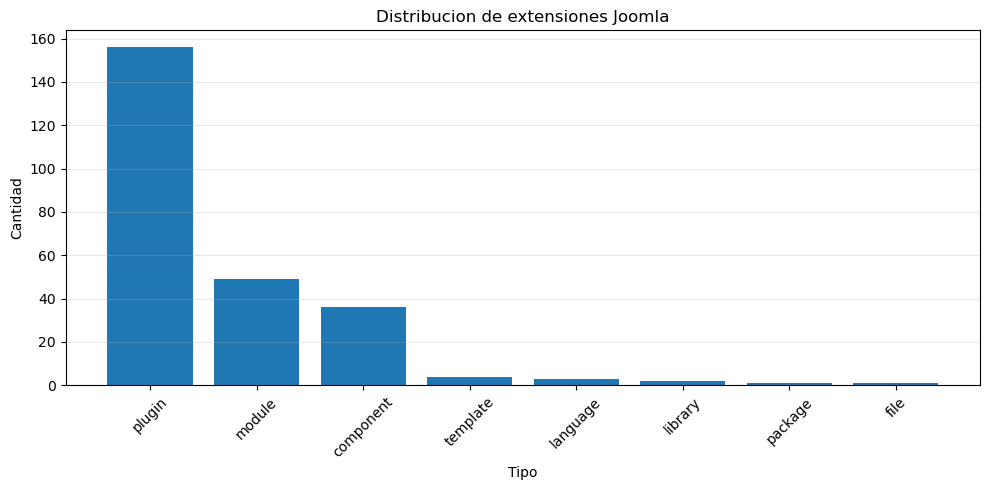

In [11]:
extensiones = pd.read_sql(
    f'''
    SELECT
        type AS tipo,
        COUNT(*) AS cantidad
    FROM "{prefijo}extensions"
    GROUP BY type
    ORDER BY cantidad DESC;
    ''',
    engine
)

display(extensiones)

plt.figure(figsize=(10,5))

plt.bar(
    extensiones["tipo"],
    extensiones["cantidad"]
)

plt.title("Distribucion de extensiones Joomla")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Tablas con mayor tamaño

,tabla,mb
0,joom_extensions,0.305
1,joom_guidedtour_steps,0.211
2,joom_workflows,0.172
3,joom_scheduler_tasks,0.156
4,joom_finder_taxonomy,0.156
5,joom_tags,0.141
6,joom_menu,0.141
7,joom_categories,0.141
8,joom_guidedtours,0.125
9,joom_workflow_transitions,0.125


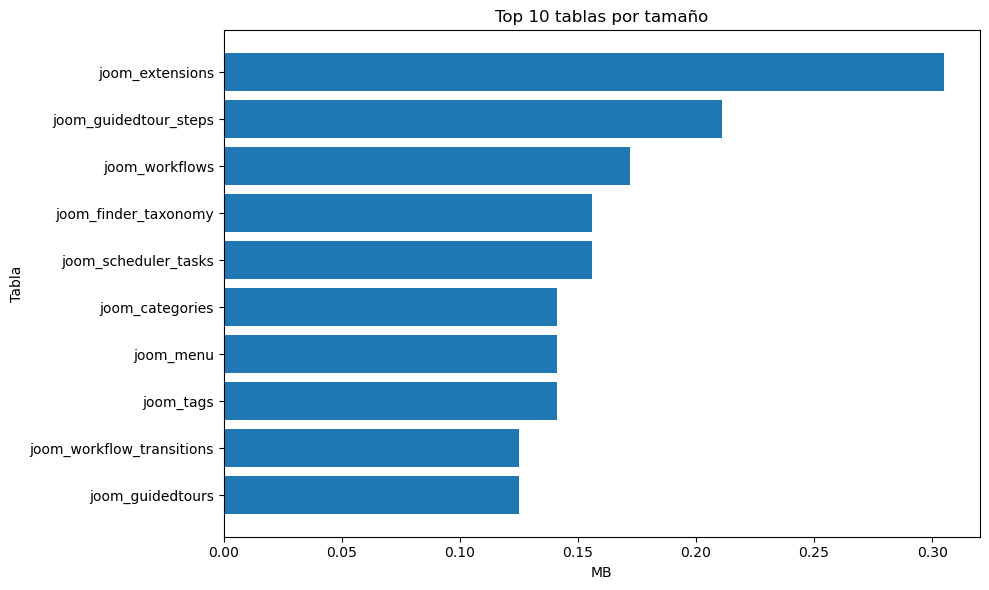

In [12]:
tamano = pd.read_sql(
    '''
    SELECT
        relname AS tabla,
        ROUND(
            pg_total_relation_size(relid)
            / 1024.0
            / 1024.0,
            3
        ) AS mb
    FROM pg_catalog.pg_statio_user_tables
    ORDER BY pg_total_relation_size(relid) DESC
    LIMIT 10;
    ''',
    engine
)

display(tamano)

grafica = tamano.sort_values("mb")

plt.figure(figsize=(10,6))

plt.barh(
    grafica["tabla"],
    grafica["mb"]
)

plt.title("Top 10 tablas por tamaño")
plt.xlabel("MB")
plt.ylabel("Tabla")
plt.tight_layout()
plt.show()


## 6. Usuarios Joomla

In [13]:
usuarios = pd.read_sql(
    f'''
    SELECT
        id,
        name AS nombre,
        username AS usuario,
        "registerDate" AS fecha_registro
    FROM "{prefijo}users"
    ORDER BY id;
    ''',
    engine
)

usuarios


,id,nombre,usuario,fecha_registro
0,32,Administrador UMNG,admin,2026-10-04 01:48:29


## 7. Actividad Joomla

In [14]:
tabla_logs = prefijo + "action_logs"

if tabla_logs in lista_tablas:

    actividad = pd.read_sql(
        f'''
        SELECT
            log_date AS fecha,
            extension,
            user_id AS usuario,
            ip_address AS ip
        FROM "{tabla_logs}"
        ORDER BY log_date DESC
        LIMIT 20;
        ''',
        engine
    )

    if actividad.empty:
        print("Todavia no existen eventos registrados.")
    else:
        display(actividad)

else:
    print("La tabla action_logs no existe.")


Todavia no existen eventos registrados.


# Conclusión

Jupyter permite analizar directamente los datos almacenados por Joomla en PostgreSQL.

Grafana se utiliza para monitoreo visual continuo, mientras que Jupyter permite ejecutar consultas, procesar información con pandas y realizar análisis adicionales mediante Python.

Todos los servicios se comunican mediante las redes internas definidas en Docker Compose.
